In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('./dataset/emails.csv')
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [3]:
df.shape

(5728, 2)

In [4]:
df['text'][0]

"Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : the  market is full of suqgestions and the information isoverwhelminq ; but a good  catchy logo , stylish statlonery and outstanding website  will make the task much easier .  we do not promise that havinq ordered a iogo your  company will automaticaily become a world ieader : it isguite ciear that  without good products , effective business organization and practicable aim it  will be hotat nowadays market ; but we do promise that your marketing efforts  will become much more effective . here is the list of clear  benefits : creativeness : hand - made , original logos , specially done  to reflect your distinctive company image . convenience : logo and stationery  are provided in all formats ; easy - to - use content management system letsyou  change your website content and even its structure . promptness : you  will see logo drafts within three business days . affordability : your  ma

##### 1. Data cleaning
##### 2. EDA
##### 3. Text Preprocessing
##### 4. Model building
##### 5. Evaluation
##### 6. Improvement


# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [6]:
# renaming the cols
df.rename(columns={'spam':'target'},inplace=True)
df.head(5)

,text,target
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [7]:
# missing value
df.isnull().sum()

text      0
target    0
dtype: int64

In [8]:
# check for duplicate values
df.duplicated().sum()

np.int64(33)

In [9]:
# remove duplicates
df = df.drop_duplicates(keep='first')
df.duplicated().sum()

np.int64(0)

# EDA - exploratory data analysis

In [10]:
df['target'].value_counts()

target
0    4327
1    1368
Name: count, dtype: int64

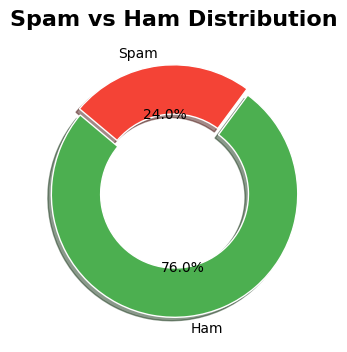

In [11]:
counts = df['target'].value_counts()

# Modern colors: Green for Ham, Red for Spam
colors = ['#4CAF50', '#F44336']  # You can adjust to your website theme

plt.figure(figsize=(4, 4))

plt.pie(
    counts,
    labels=['Ham', 'Spam'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,                    # Apply custom colors
    explode=(0.05, 0),                # Slightly pop Ham slice
    shadow=True,                       # Adds subtle shadow
    wedgeprops={'width': 0.4, 'edgecolor': 'white'}
)

plt.title('Spam vs Ham Distribution', fontsize=16, fontweight='bold')

# Save the figure for website
plt.savefig(
    "spam_vs_ham.png",
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

plt.show()

- Data is imbalanced

In [12]:
import nltk

In [13]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to C:\Users\Irfanullah's
[nltk_data]     laptop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Irfanullah's
[nltk_data]     laptop\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

1. punkt is a pre-trained tokenizer model used by NLTK to split text into:

- sentences
- words

In [14]:
df['num_characters'] = df['text'].apply(len)

In [15]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [16]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [17]:
df.head(5)

,text,target,num_characters,num_words,num_sentences
0,Subject: naturally irresistible your corporate...,1,1484,325,11
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1
2,Subject: unbelievable new homes made easy im ...,1,448,88,4
3,Subject: 4 color printing special request add...,1,500,99,5
4,"Subject: do not have money , get software cds ...",1,235,53,9


In [18]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5695.000000,5695.000000,5695.000000
mean,1558.067076,328.214047,19.462511
std,2047.078711,419.654234,35.981993
min,13.000000,3.000000,1.000000
25%,508.500000,102.000000,7.000000
50%,979.000000,211.000000,12.000000
75%,1893.000000,403.000000,22.000000
max,43952.000000,8479.000000,1565.000000


In [19]:
# ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4327.000000,4327.000000,4327.000000
mean,1634.200139,347.283799,19.838225
std,1965.016383,407.227757,38.124564
min,13.000000,3.000000,1.000000
25%,577.500000,120.000000,7.000000
50%,1122.000000,240.000000,13.000000
75%,2037.500000,440.500000,22.000000
max,43952.000000,8479.000000,1565.000000


In [20]:
# spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1368.000000,1368.000000,1368.000000
mean,1317.257310,267.896199,18.274123
std,2271.372893,451.623124,28.130434
min,18.000000,5.000000,1.000000
25%,401.500000,80.000000,6.000000
50%,693.500000,141.000000,11.000000
75%,1250.250000,252.000000,18.000000
max,28432.000000,6131.000000,438.000000


## 📊 Insights from the Descriptive Statistics

### 🔹 Overall Dataset
- The dataset contains **5,695 messages**.
- On average, a message has:
  - **1,558 characters**
  - **328 words**
  - **19 sentences**
- Message lengths vary widely (from very short to extremely long), showing **high variability**.

---

### 🔹 Spam Messages
- Total spam messages: **1,368**
- Compared to overall:
  - **Shorter on average**  
    - 1,317 characters  
    - 268 words  
    - 18 sentences  
- Spam still contains some very long messages (up to 28,432 characters), but typically tends to be shorter than ham.

---

### 🔹 Ham (Non-Spam) Messages
- Total ham messages: **4,327**
- Compared to spam:
  - **Generally longer**
    - 1,634 characters  
    - 347 words  
    - 19.8 sentences  
- Ham messages show **greater variability**, with the longest message reaching 43,952 characters.

---

### 🔹 Comparative Takeaways
- ✅ **Length is a distinguishing feature**:  
  Ham messages are typically longer than spam.
- ✅ **Sentence count is similar**, so sentence number alone may not be a strong discriminator.
- ✅ **Character/word count could be useful features** for a spam classifier.


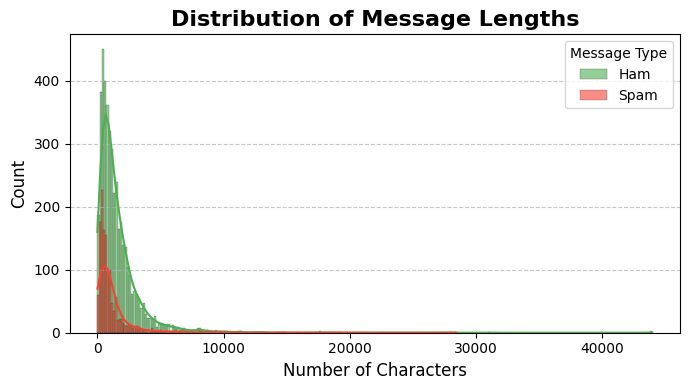

In [21]:
plt.figure(figsize=(7, 4))  # wider for website

# Plot ham (target=0)
sns.histplot(
    df[df['target'] == 0]['num_characters'], 
    color='#4CAF50',  # green
    label='Ham',
    kde=True,         # optional: smooth curve
    alpha=0.6         # transparency for overlap
)

# Plot spam (target=1)
sns.histplot(
    df[df['target'] == 1]['num_characters'], 
    color='#F44336',  # red
    label='Spam',
    kde=True,
    alpha=0.6
)

plt.title('Distribution of Message Lengths', fontsize=16, fontweight='bold')
plt.xlabel('Number of Characters', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Message Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # subtle horizontal grid
plt.tight_layout()

# Save for website
plt.savefig("message_length_distribution.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

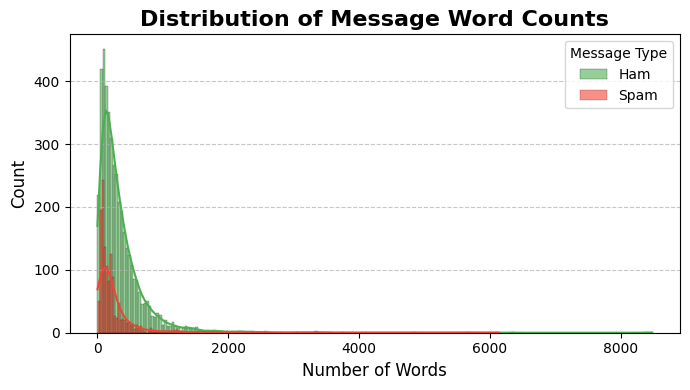

In [22]:
plt.figure(figsize=(7, 4))  # wider for website

# Ham messages (target=0)
sns.histplot(
    df[df['target'] == 0]['num_words'], 
    color='#4CAF50',  # green
    label='Ham',
    kde=True,         # smooth curve
    alpha=0.6         # transparency for overlap
)

# Spam messages (target=1)
sns.histplot(
    df[df['target'] == 1]['num_words'], 
    color='#F44336',  # red
    label='Spam',
    kde=True,
    alpha=0.6
)

plt.title('Distribution of Message Word Counts', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Message Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # subtle horizontal grid
plt.tight_layout()

# Save for website
plt.savefig("message_word_distribution.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()


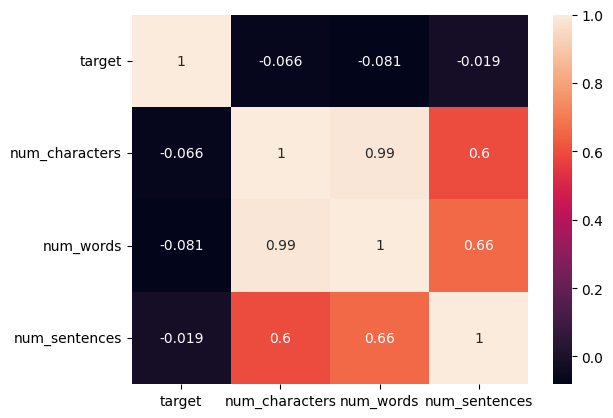

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

# Text Preprocessing
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [24]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Irfanullah's
[nltk_data]     laptop\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
import string

##### This function transforms raw text into clean, tokenized, and stemmed text suitable for NLP and machine learning models.

In [26]:
def transform_text(text):
    # 1️⃣ Convert text to lowercase
    text = text.lower()
    
    # 2️⃣ Tokenize text into words
    text = nltk.word_tokenize(text)
    
    y = []
    
    # 3️⃣ Keep only alphanumeric words (remove numbers, symbols)
    for i in text:
        if i.isalnum():
            y.append(i)
    
    text = y[:]
    y.clear()
    
    # 4️⃣ Remove stopwords and punctuation
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    # 5️⃣ Apply stemming to reduce words to their root form
    for i in text:
        y.append(ps.stem(i))
    
    # 6️⃣ Join the processed words back into a single string
    return " ".join(y)


In [27]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('getting')

'get'

------
------
------

### funtionality explained

In [28]:
sentence = "I am running and playing while talking to my friends about amazing wins!"
sentence = sentence.lower()

- Split string in list of words and punctuation

In [29]:
l = nltk.word_tokenize(sentence)
print(l)

['i', 'am', 'running', 'and', 'playing', 'while', 'talking', 'to', 'my', 'friends', 'about', 'amazing', 'wins', '!']


- Only include alphanumeric values

In [30]:
l2 = []
for i in l:
        if i.isalnum():
            l2.append(i)
l = l2[:]
print(l)


['i', 'am', 'running', 'and', 'playing', 'while', 'talking', 'to', 'my', 'friends', 'about', 'amazing', 'wins']


- Keep only the words that are not stopwords **['the', 'is', 'and', 'a', 'to', 'am', 'there', 'how', 'also', 'you']** and not punctuation.

In [31]:
l2.clear()
for i in l:
    if i not in stopwords.words('english') and i not in string.punctuation:
        l2.append(i)

l = l2[:]
print(l)

['running', 'playing', 'talking', 'friends', 'amazing', 'wins']


## 🌱 Stemming in NLP

**Definition:**  
Stemming reduces words to their **root form** by removing prefixes/suffixes. The stem may not be a valid English word but is useful for NLP.

**Examples:**

| Original Word | Stemmed Word |
|---------------|--------------|
| running       | run          |
| played        | play         |
| talks         | talk         |
| amazing       | amaz         |
| leaves        | leav         |


In [32]:
l2.clear()
for i in l:
    l2.append(ps.stem(i))
print(l2)

['run', 'play', 'talk', 'friend', 'amaz', 'win']


In [33]:
" ".join(l2)

'run play talk friend amaz win'

-----
-----

In [34]:
transform_text('Congratulations! You have won a FREE ticket. Call now to claim your prize.')

'congratul free ticket call claim prize'

In [35]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head(5)

,text,target,num_characters,num_words,num_sentences,transformed_text
0,Subject: naturally irresistible your corporate...,1,1484,325,11,subject natur irresist corpor ident lt realli ...
1,Subject: the stock trading gunslinger fanny i...,1,598,90,1,subject stock trade gunsling fanni merril muzo...
2,Subject: unbelievable new homes made easy im ...,1,448,88,4,subject unbeliev new home made easi im want sh...
3,Subject: 4 color printing special request add...,1,500,99,5,subject 4 color print special request addit in...
4,"Subject: do not have money , get software cds ...",1,235,53,9,subject money get softwar cd softwar compat gr...


In [36]:
df['transformed_text'] = df['transformed_text'].str.replace('subject ','')

- Now we plot word cloud for both categories

In [37]:
from wordcloud import WordCloud

In [38]:
wc = WordCloud(width=1500,height=1500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

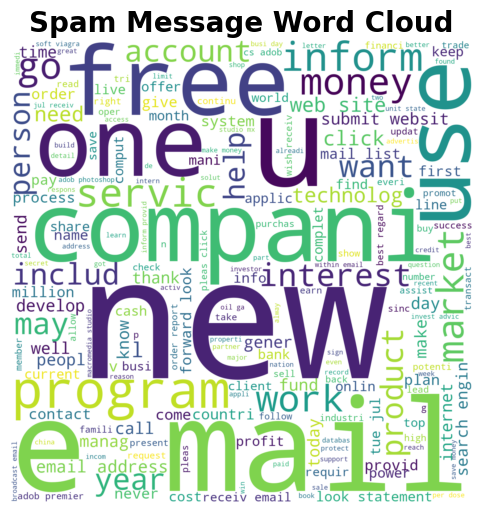

In [39]:
plt.figure(figsize=(15, 6))

# Display word cloud
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')  # hide axes for clean look
plt.title('Spam Message Word Cloud', fontsize=20, fontweight='bold')

# Save for website
plt.savefig("spam_wordcloud.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

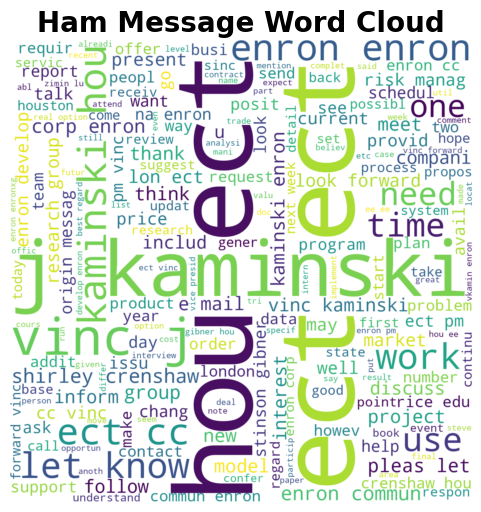

In [40]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

plt.figure(figsize=(15, 6))
plt.imshow(ham_wc, interpolation='bilinear')  # smooth edges
plt.axis('off')  # hide axes for clean look
plt.title('Ham Message Word Cloud', fontsize=20, fontweight='bold')

# Save for website
plt.savefig("ham_wordcloud.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

## Lets see Top 30 words used in both categories

In [41]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [42]:
from collections import Counter
spam_top30 = pd.DataFrame(Counter(spam_corpus).most_common(30))
spam_top30.head(3)

,0,1
0,compani,1065
1,com,1000
2,1,952


C:\Users\Irfanullah's laptop\AppData\Local\Temp\ipykernel_6880\1350547379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


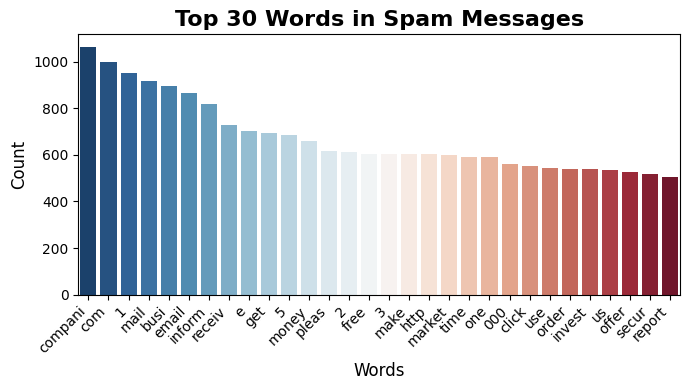

In [43]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=spam_top30[0],
    y=spam_top30[1],
    palette='RdBu_r'  # reversed RdBu for better readability
)

plt.xticks(rotation=45, ha='right', fontsize=10)  # tilted for readability
plt.yticks(fontsize=10)
plt.title('Top 30 Words in Spam Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# Save for website
plt.savefig("spam_top30_barplot.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

In [44]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [45]:
ham_top30 = pd.DataFrame(Counter(ham_corpus).most_common(30))
ham_top30.head(3)

,0,1
0,enron,13335
1,ect,11410
2,vinc,8468


C:\Users\Irfanullah's laptop\AppData\Local\Temp\ipykernel_6880\3689910319.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


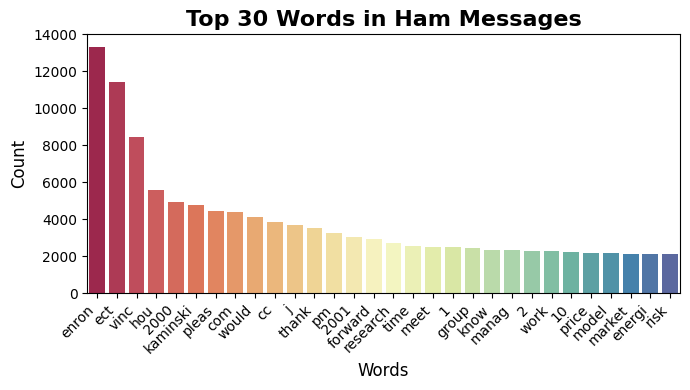

In [46]:
plt.figure(figsize=(7,4))

sns.barplot(
    x=ham_top30[0],
    y=ham_top30[1],
    palette='Spectral'  # nice color gradient
)

plt.xticks(rotation=45, ha='right', fontsize=10)  # tilted for readability
plt.yticks(fontsize=10)
plt.title('Top 30 Words in Ham Messages', fontsize=16, fontweight='bold')
plt.xlabel('Words', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()

# Save for website
plt.savefig("ham_top30_barplot.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

# Model Building 

In [47]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score

#### Checking performance with both vectorization technique one by one from following and use the one that's performing better:

#### 1. Bag Of words

In [48]:
cv = CountVectorizer()
X = cv.fit_transform(df['transformed_text']).toarray()

#### 2. TFIDF vectorizer

In [49]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [50]:
X.shape

(5695, 5000)

In [51]:
y = df['target'].values

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [53]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [54]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))
print(recall_score(y_test,y_pred1))

0.9508340649692713
[[841   8]
 [ 48 242]]
0.968
0.8344827586206897


In [55]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))
print(recall_score(y_test,y_pred2))

0.9824407374890255
[[848   1]
 [ 19 271]]
0.9963235294117647
0.9344827586206896


In [56]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))
print(recall_score(y_test,y_pred3))

0.9578577699736611
[[802  47]
 [  1 289]]
0.8601190476190477
0.996551724137931


- -> Choosing mnb is a good choice here because precision is 99.6% means there is no false spamming

#### Lets try more different models

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB,BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [58]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
bnb = BernoulliNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

In [59]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'MNB': mnb,
    'BNB' : bnb,
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc 
}

In [60]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    return accuracy,precision,recall
    
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.990342405618964, 0.9929328621908127, 0.9689655172413794)

In [61]:
accuracy_scores = []
precision_scores = []
recall_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision, current_recall = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)

For  SVC
Accuracy -  0.990342405618964
Precision -  0.9929328621908127
For  KN
Accuracy -  0.9771729587357331
Precision -  0.9583333333333334
For  MNB
Accuracy -  0.9824407374890255
Precision -  0.9963235294117647
For  BNB
Accuracy -  0.9578577699736611
Precision -  0.8601190476190477
For  DT
Accuracy -  0.9236172080772608
Precision -  0.8048048048048048
For  LR
Accuracy -  0.974539069359087
Precision -  0.9745454545454545
For  RF
Accuracy -  0.9789288849868305
Precision -  0.9683098591549296


In [62]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores,'Recall' : recall_scores}).sort_values('Precision',ascending=False)

In [63]:
performance_df

,Algorithm,Accuracy,Precision,Recall
2,MNB,0.982441,0.996324,0.934483
0,SVC,0.990342,0.992933,0.968966
5,LR,0.974539,0.974545,0.924138
6,RF,0.978929,0.968310,0.948276
1,KN,0.977173,0.958333,0.951724
3,BNB,0.957858,0.860119,0.996552
4,DT,0.923617,0.804805,0.924138


- Precision matter more in this problem
- but there is no big difference in Precision of svc and mnb here
- Additionally SVC is giving highest accuracy and very high recall.
## *SVC* is best model.

In [64]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,MNB,Accuracy,0.982441
1,SVC,Accuracy,0.990342
2,LR,Accuracy,0.974539
3,RF,Accuracy,0.978929
4,KN,Accuracy,0.977173
5,BNB,Accuracy,0.957858
6,DT,Accuracy,0.923617
7,MNB,Precision,0.996324
8,SVC,Precision,0.992933
9,LR,Precision,0.974545


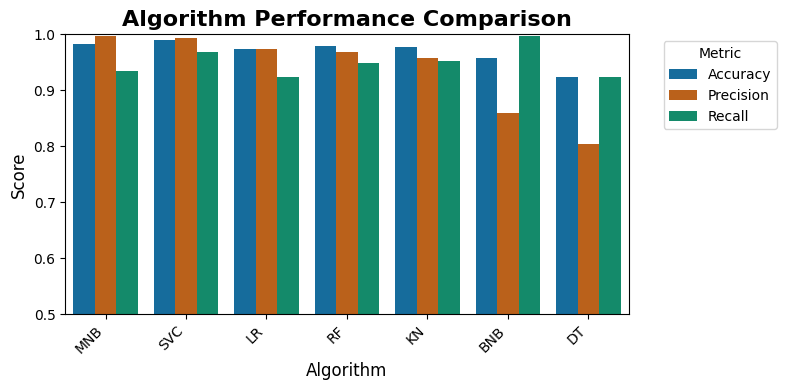

In [65]:
plt.figure(figsize=(8,4))

# Create grouped bar chart with custom colors
sns.barplot(
    x='Algorithm', 
    y='value', 
    hue='variable', 
    data=performance_df1, 
    palette=['#0072B2', '#D55E00', '#009E73']  # blue, red, green for good contrast
)

plt.ylim(0.5, 1.0)  # y-axis limits
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel('Algorithm', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Algorithm Performance Comparison', fontsize=16, fontweight='bold')

# Move legend outside plot
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

# Save for website
plt.savefig("algorithm_performance.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()


In [66]:
### Lets make a voting classsifier using 3 best performing models

In [67]:
mnb = MultinomialNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)

In [68]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('lr', lrc), ('mnb', mnb),('svc', svc )],voting='soft')

In [69]:
voting.fit(X_train,y_train)

,estimators,"[('lr', ...), ('mnb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [70]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))

Accuracy 0.9920983318700615
Precision 0.9929824561403509
Recall 0.9758620689655172


In [71]:
svc = SVC(kernel='sigmoid', gamma=1.0)
svc.fit(X_train,y_train)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,1.0
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [72]:
# 1️⃣ Make predictions
y_pred_voting = voting.predict(X_test)        # Voting Classifier
y_pred_svc = svc.predict(X_test)             # Multinomial Naive Bayes

# 2️⃣ Calculate performance metrics
results = []

for model_name, y_pred in [('Voting Classifier', y_pred_voting), 
                           ('SVC', y_pred_svc)]:
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec 
    })
    
performance_df = pd.DataFrame(results)
performance_df

,Model,Accuracy,Precision,Recall
0,Voting Classifier,0.992098,0.992982,0.975862
1,SVC,0.990342,0.992933,0.968966


- **Voting Classifier** is the best model as it achieves higher accuracy, precision, and recall than SVC.  
- It provides more robust and stable performance by combining multiple classifiers.


In [73]:
performance_melted = performance_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
performance_melted

,Model,Metric,Score
0,Voting Classifier,Accuracy,0.992098
1,SVC,Accuracy,0.990342
2,Voting Classifier,Precision,0.992982
3,SVC,Precision,0.992933
4,Voting Classifier,Recall,0.975862
5,SVC,Recall,0.968966


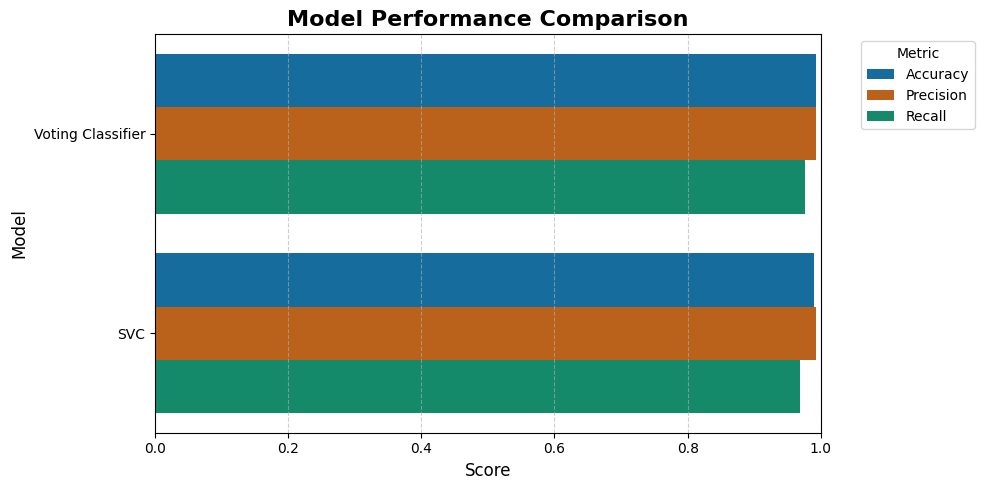

In [74]:
plt.figure(figsize=(10,5))

# Horizontal barplot with thinner bars
sns.barplot(
    x='Score', 
    y='Model', 
    hue='Metric', 
    data=performance_melted, 
    palette=['#0072B2', '#D55E00', '#009E73'], 
    dodge=True  # separate bars for each metric
)

plt.xlim(0,1)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)  # subtle vertical grid

# Legend outside
plt.legend(title='Metric', bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

# Save for website
plt.savefig("model_performance_comparison.png", dpi=300, bbox_inches='tight', transparent=True)

plt.show()

In [75]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))

----